# PSFField Forced Photometry Validation

This notebook is the first diagnostic pass for the PSF + photometry stage.

Goals:
1. Load the current `PSFField` checkpoint.
2. Use the v8 CenterNet detector to build a VIS-frame master source catalog.
3. Project the same master objects into Rubin and Euclid native pixels.
4. Run forced matched-filter photometry on real Rubin-native and Euclid-native tiles.
5. Inspect flux, SNR, chi2/dof, and data/model/residual stamps.
6. Provide an optional overlap-repeatability scaffold for repeated sources in overlapping tiles.

Important convention: this notebook validates **photometry**, not astrometry training labels. The current astrometry correction remains the v8 latent position head; PSFField centroids are not used as latent-head targets here.


In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.origin'] = 'lower'


def find_repo_root(start: Path = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / 'models').exists() and (cand / 'data').exists():
            return cand
    return start

ROOT = find_repo_root()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'models'))

from models.photometry import PSFFieldPhotometryPipeline
from load_foundation import load_foundation
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper
from astrometry2.source_matching import detect_sources, build_detection_image, RUBIN_BAND_ORDER
from astrometry2.dataset import _to_float32, detect_sources_multiband
from astrometry2.source_matching import safe_header_from_card_string

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'ROOT   = {ROOT}')
print(f'DEVICE = {DEVICE}')


ROOT   = /home/shemmati/Work/Projects/JAISP
DEVICE = cuda


## Configuration

The defaults are intentionally small so the notebook is quick to execute. Increase `MAX_SOURCES` or turn on `RUN_OVERLAP` after the first pass looks sane.


In [2]:
RUBIN_DIR = ROOT / 'data' / 'rubin_tiles_all'
EUCLID_DIR = ROOT / 'data' / 'euclid_tiles_all'
PSF_CKPT = ROOT / 'models' / 'checkpoints' / 'psf_field_v3.pt'
FOUNDATION_CKPT = ROOT / 'models' / 'checkpoints' / 'jaisp_v8_fine' / 'checkpoint_best.pt'
CENTERNET_CKPT = ROOT / 'checkpoints' / 'centernet_v8_fine' / 'centernet_best.pt'
OUT_DIR = ROOT / 'io'

MAX_SOURCES = 80
STAMP_SIZE = 25
SUB_GRID = 2          # use 1 for fastest CPU smoke tests; 2-4 for better pixel integration
BG_INNER = 8.0
BG_OUTER = 11.5

USE_CENTERNET = True
CENTERNET_CONF = 0.30
CENTERNET_FALLBACK_TO_CLASSICAL_VIS = True

RUN_OVERLAP = False   # set True for the repeatability section near the end
N_OVERLAP_TILES = 8
OVERLAP_SOURCES_PER_TILE = 60

for label, path in [
    ('Rubin dir', RUBIN_DIR),
    ('Euclid dir', EUCLID_DIR),
    ('PSF checkpoint', PSF_CKPT),
    ('Foundation', FOUNDATION_CKPT),
    ('CenterNet', CENTERNET_CKPT),
]:
    print(f'{label:15s}: {path.relative_to(ROOT) if path.exists() else path}  {"OK" if path.exists() else "MISSING"}')


Rubin dir      : data/rubin_tiles_all  OK
Euclid dir     : data/euclid_tiles_all  OK
PSF checkpoint : models/checkpoints/psf_field_v3.pt  OK
Foundation     : models/checkpoints/jaisp_v8_fine/checkpoint_best.pt  OK
CenterNet      : checkpoints/centernet_v8_fine/centernet_best.pt  OK


## Helpers


In [3]:
def load_rubin_tile(path: Path):
    data = np.load(path, allow_pickle=True)
    img = np.nan_to_num(data['img'].astype('float32'), nan=0.0)
    var = data['var'].astype('float32') if 'var' in data else np.ones_like(img, dtype='float32')
    rms = np.sqrt(np.clip(var, 1e-8, None)).astype('float32')
    wcs = WCS(data['wcs_hdr'].item())
    tile_id = str(data['tile_id']) if 'tile_id' in data else path.stem
    return {'path': path, 'tile_id': tile_id, 'img': img, 'var': var, 'rms': rms, 'wcs': wcs}


def load_euclid_tile(path: Path):
    data = np.load(path, allow_pickle=True)
    band_keys = ['VIS', 'Y', 'J', 'H']
    imgs, rms, wcs = [], [], []
    for band in band_keys:
        img = np.nan_to_num(_to_float32(data[f'img_{band}']), nan=0.0)
        var = _to_float32(data[f'var_{band}']) if f'var_{band}' in data else np.ones_like(img, dtype='float32')
        imgs.append(img)
        rms.append(np.sqrt(np.clip(var, 1e-8, None)).astype('float32'))
        wcs.append(WCS(safe_header_from_card_string(data[f'wcs_{band}'].item())))
    return {
        'path': path,
        'tile_id': path.stem.replace('_euclid', ''),
        'img': np.stack(imgs).astype('float32'),
        'rms': np.stack(rms).astype('float32'),
        'wcs': wcs,
        'band_names': ['euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H'],
    }


def rank_positions(image, x, y, margin, max_sources):
    if len(x) == 0:
        return torch.zeros((0, 2), dtype=torch.float32)
    H, W = image.shape
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    keep = (x >= margin) & (x < W - margin) & (y >= margin) & (y < H - margin)
    x, y = x[keep], y[keep]
    if len(x) == 0:
        return torch.zeros((0, 2), dtype=torch.float32)
    xi = np.clip(np.round(x).astype(int), 0, W - 1)
    yi = np.clip(np.round(y).astype(int), 0, H - 1)
    score = image[yi, xi]
    order = np.argsort(score)[::-1][:max_sources]
    return torch.from_numpy(np.stack([x[order], y[order]], axis=1).astype('float32'))


def project_xy(source_xy, source_wcs, target_wcs):
    source_xy = np.asarray(source_xy, dtype=np.float32)
    if source_xy.size == 0:
        return np.zeros((0, 2), dtype=np.float32)
    ra, dec = source_wcs.wcs_pix2world(source_xy[:, 0], source_xy[:, 1], 0)
    tx, ty = target_wcs.wcs_world2pix(ra, dec, 0)
    return np.stack([tx, ty], axis=1).astype('float32')


def _in_margin(xy, shape, margin):
    H, W = shape
    xy = np.asarray(xy, dtype=np.float32)
    return (
        np.isfinite(xy[:, 0]) & np.isfinite(xy[:, 1]) &
        (xy[:, 0] >= margin) & (xy[:, 0] < W - margin) &
        (xy[:, 1] >= margin) & (xy[:, 1] < H - margin)
    )


def load_centernet_detector():
    if not USE_CENTERNET:
        return None
    missing = [p for p in (FOUNDATION_CKPT, CENTERNET_CKPT) if not p.exists()]
    if missing:
        print('CenterNet disabled; missing:', ', '.join(str(p.relative_to(ROOT)) for p in missing))
        return None
    foundation = load_foundation(str(FOUNDATION_CKPT), device=torch.device('cpu'), freeze=True)
    encoder = JAISPEncoderWrapper(foundation, freeze=True)
    detector = CenterNetDetector.load(str(CENTERNET_CKPT), encoder, device=DEVICE).eval()
    print(f'Loaded CenterNet detector: {CENTERNET_CKPT.relative_to(ROOT)}')
    return detector


def select_master_positions(vis_xy, rubin, euclid, max_sources=MAX_SOURCES, margin=None):
    margin = margin or (STAMP_SIZE // 2 + 2)
    vis_xy = np.asarray(vis_xy, dtype=np.float32)
    rubin_xy = project_xy(vis_xy, euclid['wcs'][0], rubin['wcs'])
    keep = _in_margin(vis_xy, euclid['img'][0].shape, margin) & _in_margin(rubin_xy, rubin['img'][0].shape, margin)
    vis_xy = vis_xy[keep]
    rubin_xy = rubin_xy[keep]
    if len(vis_xy) == 0:
        return torch.zeros((0, 2)), torch.zeros((0, 2))
    xi = np.clip(np.round(vis_xy[:, 0]).astype(int), 0, euclid['img'][0].shape[1] - 1)
    yi = np.clip(np.round(vis_xy[:, 1]).astype(int), 0, euclid['img'][0].shape[0] - 1)
    score = euclid['img'][0][yi, xi]
    order = np.argsort(score)[::-1][:max_sources]
    return (
        torch.from_numpy(vis_xy[order].astype('float32')),
        torch.from_numpy(rubin_xy[order].astype('float32')),
    )


def detect_classical_vis_master_positions(rubin, euclid, max_sources=MAX_SOURCES, margin=None):
    margin = margin or (STAMP_SIZE // 2 + 2)
    vis = euclid['img'][0]
    x, y = detect_sources(vis, nsig=4.0, smooth_sigma=1.2, min_dist=9, max_sources=1500)
    vis_xy = rank_positions(vis, x, y, margin=margin, max_sources=max_sources * 3).numpy()
    return select_master_positions(vis_xy, rubin, euclid, max_sources=max_sources, margin=margin)


def detect_centernet_master_positions(rubin, euclid, detector, max_sources=MAX_SOURCES, margin=None):
    if detector is None:
        return detect_classical_vis_master_positions(rubin, euclid, max_sources=max_sources, margin=margin)
    edata = np.load(euclid['path'], allow_pickle=True)
    x, y = detect_sources_multiband(
        edata,
        rubin['img'],
        rubin.get('var'),
        detector,
        DEVICE,
        conf_threshold=CENTERNET_CONF,
    )
    print(f'CenterNet raw detections: {len(x)}')
    vis_xy = np.stack([x, y], axis=1).astype('float32') if len(x) else np.zeros((0, 2), dtype='float32')
    vis_pos, rubin_pos = select_master_positions(vis_xy, rubin, euclid, max_sources=max_sources, margin=margin)
    if len(vis_pos) == 0 and CENTERNET_FALLBACK_TO_CLASSICAL_VIS:
        print('CenterNet produced no usable in-bounds sources; falling back to classical VIS.')
        return detect_classical_vis_master_positions(rubin, euclid, max_sources=max_sources, margin=margin)
    return vis_pos, rubin_pos


def detect_rubin_positions(rubin, max_sources=MAX_SOURCES, margin=None):
    margin = margin or (STAMP_SIZE // 2 + 2)
    det_img = build_detection_image(rubin['img'], ['rubin_g', 'rubin_r', 'rubin_i', 'rubin_z'])
    x, y = detect_sources(det_img, nsig=4.0, smooth_sigma=1.0, min_dist=7, max_sources=1200)
    return rank_positions(det_img, x, y, margin=margin, max_sources=max_sources)


def detect_euclid_positions(euclid, max_sources=MAX_SOURCES, margin=None):
    margin = margin or (STAMP_SIZE // 2 + 2)
    vis = euclid['img'][0]
    x, y = detect_sources(vis, nsig=4.0, smooth_sigma=1.2, min_dist=9, max_sources=1500)
    return rank_positions(vis, x, y, margin=margin, max_sources=max_sources)


def as_tensor(x):
    return torch.from_numpy(np.asarray(x, dtype='float32'))


def summarize_result(out, title):
    flux = out['flux'].detach().cpu().numpy()
    ferr = out['flux_err'].detach().cpu().numpy()
    snr = out['snr'].detach().cpu().numpy()
    chi2 = out['chi2_dof'].detach().cpu().numpy()
    bands = out['band_names']
    print(title)
    print(f'  flux finite: {np.isfinite(flux).all()}')
    print(f'  chi2 finite: {np.isfinite(chi2).all()}')
    print(f'  N sources: {flux.shape[0]}, bands: {bands}')
    for i, band in enumerate(bands):
        good = np.isfinite(snr[:, i]) & np.isfinite(chi2[:, i])
        print(f'  {band:10s}  med SNR={np.nanmedian(snr[good, i]):8.2f}  '
              f'p90 SNR={np.nanpercentile(snr[good, i], 90):8.2f}  '
              f'med chi2={np.nanmedian(chi2[good, i]):8.2f}')


def plot_summary(out, title, save_path=None):
    bands = out['band_names']
    snr = out['snr'].detach().cpu().numpy()
    chi2 = out['chi2_dof'].detach().cpu().numpy()
    flux = out['flux'].detach().cpu().numpy()
    ferr = out['flux_err'].detach().cpu().numpy()
    pull_flux = flux / np.clip(ferr, 1e-20, None)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for b, band in enumerate(bands):
        axes[0].hist(snr[:, b], bins=np.linspace(-20, 80, 80), histtype='step', lw=1.4, label=band)
        finite_chi = chi2[np.isfinite(chi2[:, b]), b]
        finite_chi = finite_chi[(finite_chi > 0) & (finite_chi < np.nanpercentile(finite_chi, 99.5))]
        axes[1].hist(finite_chi, bins=80, histtype='step', lw=1.4, label=band)
        axes[2].scatter(snr[:, b], chi2[:, b], s=6, alpha=0.35, label=band)

    axes[0].set_title('SNR distribution')
    axes[0].set_xlabel('flux / flux_err')
    axes[0].set_ylabel('count')
    axes[0].legend(fontsize=7)
    axes[0].grid(alpha=0.2)

    axes[1].set_title('chi2/dof distribution')
    axes[1].set_xlabel('chi2/dof')
    axes[1].set_ylabel('count')
    axes[1].set_yscale('log')
    axes[1].grid(alpha=0.2)

    axes[2].set_title('chi2/dof vs SNR')
    axes[2].set_xlabel('SNR')
    axes[2].set_ylabel('chi2/dof')
    axes[2].set_xlim(-10, min(100, np.nanpercentile(pull_flux, 99)))
    axes[2].set_ylim(0, min(200, np.nanpercentile(chi2[np.isfinite(chi2)], 98)))
    axes[2].grid(alpha=0.2)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved {Path(save_path).relative_to(ROOT)}')
    plt.show()


def plot_stamp_gallery(out, band=0, n_show=8, mode='worst_chi2', title='', save_path=None):
    bands = out['band_names']
    data = out['stamps_sub'].detach().cpu().numpy()
    model = out['model'].detach().cpu().numpy()
    resid = out['resid'].detach().cpu().numpy()
    chi2 = out['chi2_dof'].detach().cpu().numpy()
    snr = out['snr'].detach().cpu().numpy()

    if mode == 'good_chi2':
        good = np.isfinite(chi2[:, band]) & np.isfinite(snr[:, band]) & (snr[:, band] > 10)
        candidates = np.where(good)[0]
        if len(candidates) == 0:
            candidates = np.where(np.isfinite(chi2[:, band]))[0]
        order = candidates[np.argsort(chi2[candidates, band])]
    elif mode == 'worst_chi2':
        order = np.argsort(np.nan_to_num(chi2[:, band], nan=-np.inf))[::-1]
    elif mode == 'best_snr':
        order = np.argsort(np.nan_to_num(snr[:, band], nan=-np.inf))[::-1]
    else:
        order = np.arange(data.shape[0])
    order = order[:n_show]

    fig, axes = plt.subplots(len(order), 3, figsize=(8.5, 2.25 * len(order)))
    if len(order) == 1:
        axes = axes[None, :]
    for row, idx in enumerate(order):
        d = data[idx, band]
        m = model[idx, band]
        r = resid[idx, band]
        vmax = np.nanpercentile(np.abs(d), 98)
        rv = np.nanpercentile(np.abs(r), 98)
        panels = [(d, 'data-bg', -vmax, vmax), (m, 'PSF model', 0, np.nanpercentile(m, 99)), (r, 'residual', -rv, rv)]
        for col, (arr, label, vmin, vmax_i) in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(arr, cmap='magma' if col != 2 else 'coolwarm', vmin=vmin, vmax=vmax_i)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(label)
        axes[row, 0].set_ylabel(f'#{idx}\nSNR={snr[idx, band]:.1f}\nchi2={chi2[idx, band]:.1f}', fontsize=8)

    fig.suptitle(f'{title} - {bands[band]} ({mode})', y=1.01)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved {Path(save_path).relative_to(ROOT)}')
    plt.show()


## 1. Load a Matched Tile Pair


In [4]:
pair_map = {}
for rp in sorted(RUBIN_DIR.glob('tile_x*_y*.npz')):
    ep = EUCLID_DIR / f'{rp.stem}_euclid.npz'
    if ep.exists():
        pair_map[rp.stem] = (rp, ep)

print(f'Matched tile pairs: {len(pair_map)}')
first_tid = sorted(pair_map)[0]
rubin = load_rubin_tile(pair_map[first_tid][0])
euclid = load_euclid_tile(pair_map[first_tid][1])
print(f'Using tile: {first_tid}')
print(f'Rubin image shape:  {rubin["img"].shape}')
print(f'Euclid image shape: {euclid["img"].shape}')


Matched tile pairs: 790
Using tile: tile_x00000_y00000_tract5063_patch_14
Rubin image shape:  (6, 512, 512)
Euclid image shape: (4, 1084, 1084)


## 2. Build CenterNet Master Catalog

CenterNet predicts source positions on the Euclid VIS grid using the full multi-band tile. We use those VIS-frame positions as the master object list, then project the same objects into Rubin pixels for Rubin-native forced photometry.


In [5]:
detector = load_centernet_detector()
vis_master_pos, rubin_master_pos = detect_centernet_master_positions(
    rubin,
    euclid,
    detector,
    max_sources=MAX_SOURCES,
)
print(f'Master VIS positions:   {len(vis_master_pos)}')
print(f'Projected Rubin pixels: {len(rubin_master_pos)}')


JAISPFoundationV8: 9.1M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v8 foundation (fused_scale=0.4) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v8_fine/checkpoint_best.pt
Loaded CenterNet detector: checkpoints/centernet_v8_fine/centernet_best.pt
CenterNet raw detections: 209
Master VIS positions:   80
Projected Rubin pixels: 80


## 3. Rubin-Native Forced Photometry

This runs on native Rubin pixels, so Rubin bands use the default 0.2 arcsec/pixel PSFField rendering. Positions come from the CenterNet VIS master catalog projected through WCS into the Rubin tile. That makes this a forced-photometry test on a shared object list, not a separate Rubin coadd detection test.


In [6]:
rubin_bands = ['rubin_g', 'rubin_r', 'rubin_i', 'rubin_z']
rubin_idx = [RUBIN_BAND_ORDER.index(b.split('_', 1)[1]) for b in rubin_bands]
rubin_pos = rubin_master_pos
print(f'Rubin forced-photometry positions: {len(rubin_pos)}')

rubin_pipe = PSFFieldPhotometryPipeline.from_checkpoint(
    PSF_CKPT,
    band_names=rubin_bands,
    stamp_size=STAMP_SIZE,
    sub_grid=SUB_GRID,
    bg_inner_radius=BG_INNER,
    bg_outer_radius=BG_OUTER,
    device=DEVICE,
)

rubin_tile = as_tensor(rubin['img'][rubin_idx])
rubin_rms = as_tensor(rubin['rms'][rubin_idx])
rubin_out = rubin_pipe.run(rubin_tile, rubin_rms, rubin_pos, return_psfs=True, return_stamps=True)
summarize_result(rubin_out, 'Rubin-native PSFField forced photometry on CenterNet master catalog')


Rubin forced-photometry positions: 80
Rubin-native PSFField forced photometry on CenterNet master catalog
  flux finite: True
  chi2 finite: True
  N sources: 80, bands: ['rubin_g', 'rubin_r', 'rubin_i', 'rubin_z']
  rubin_g     med SNR=   44.87  p90 SNR=  224.59  med chi2=    1.09
  rubin_r     med SNR=   60.75  p90 SNR=  407.02  med chi2=    1.97
  rubin_i     med SNR=   63.83  p90 SNR=  424.76  med chi2=    1.90
  rubin_z     med SNR=   39.97  p90 SNR=  275.35  med chi2=    0.83


Saved io/psf_field_photometry_rubin_summary.png


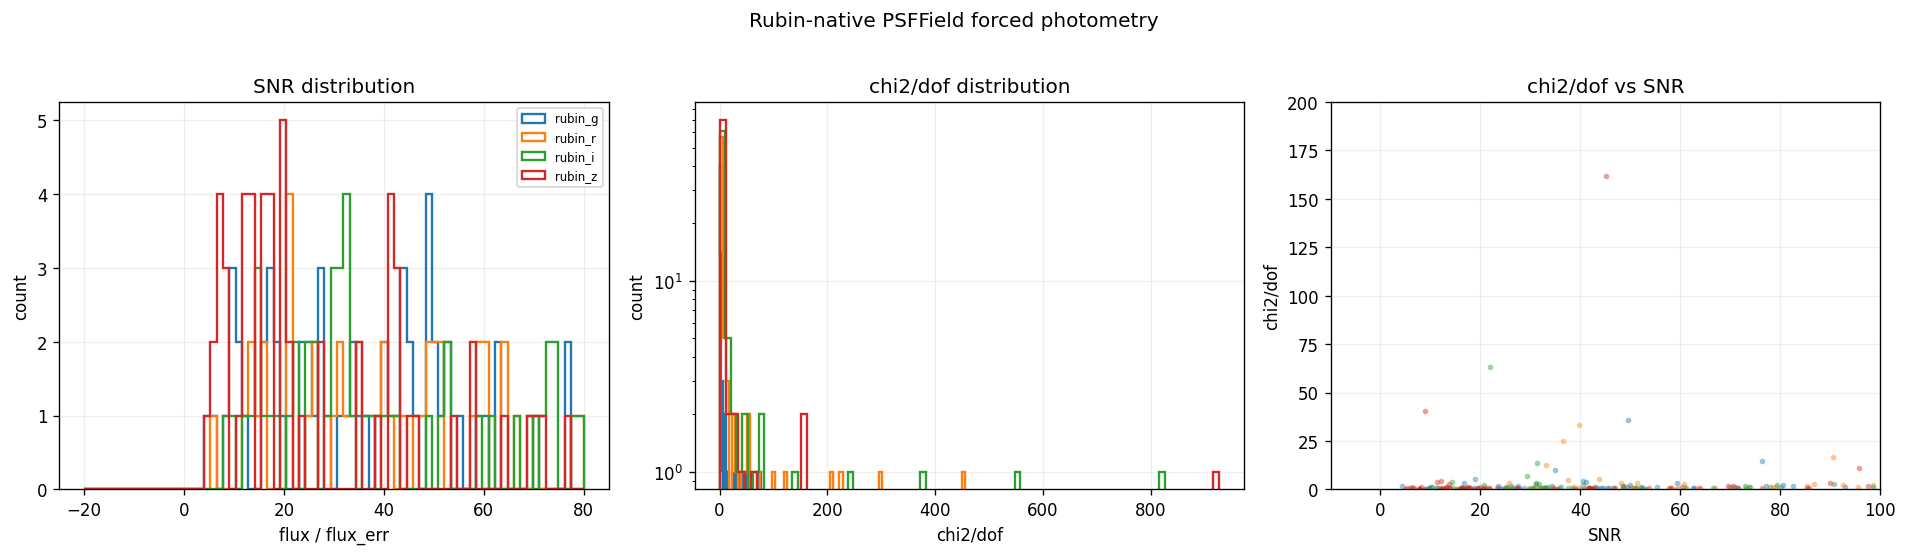

Saved io/psf_field_photometry_rubin_good_gallery.png


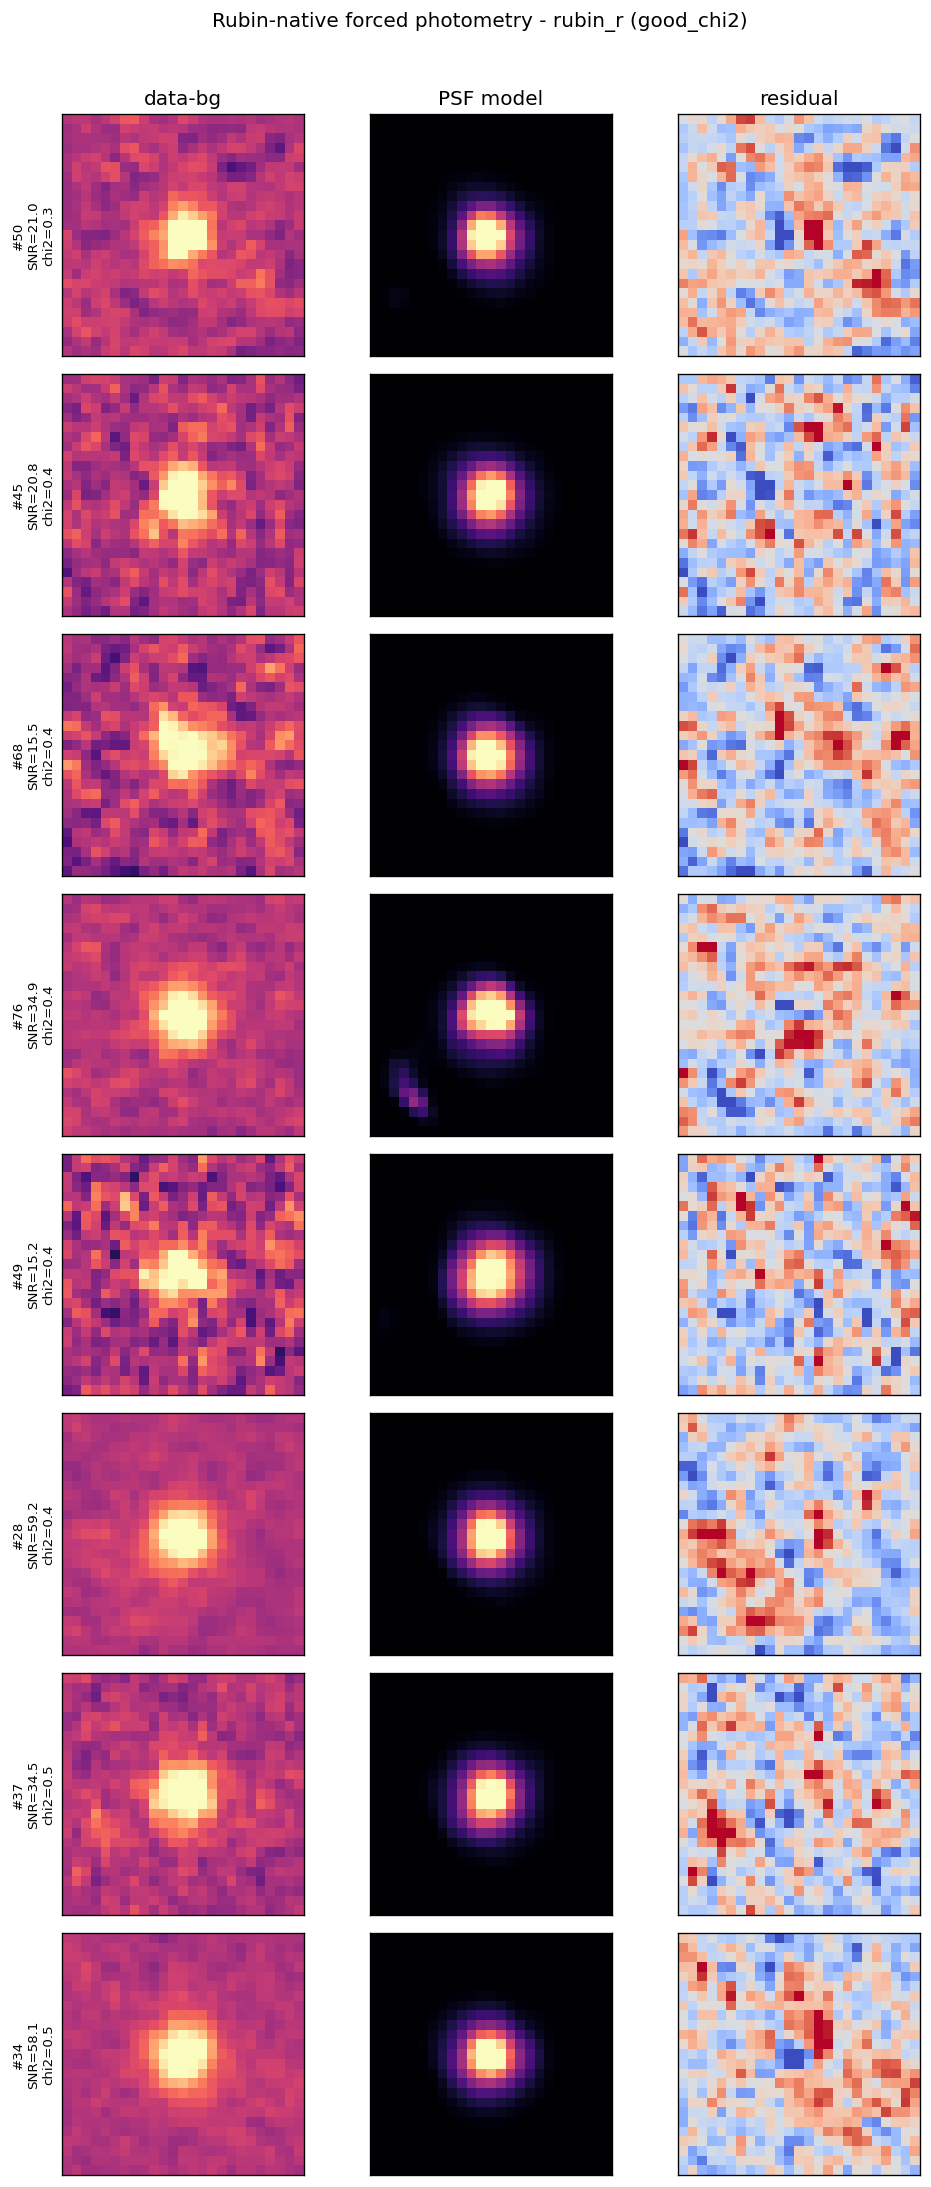

Saved io/psf_field_photometry_rubin_worst_gallery.png


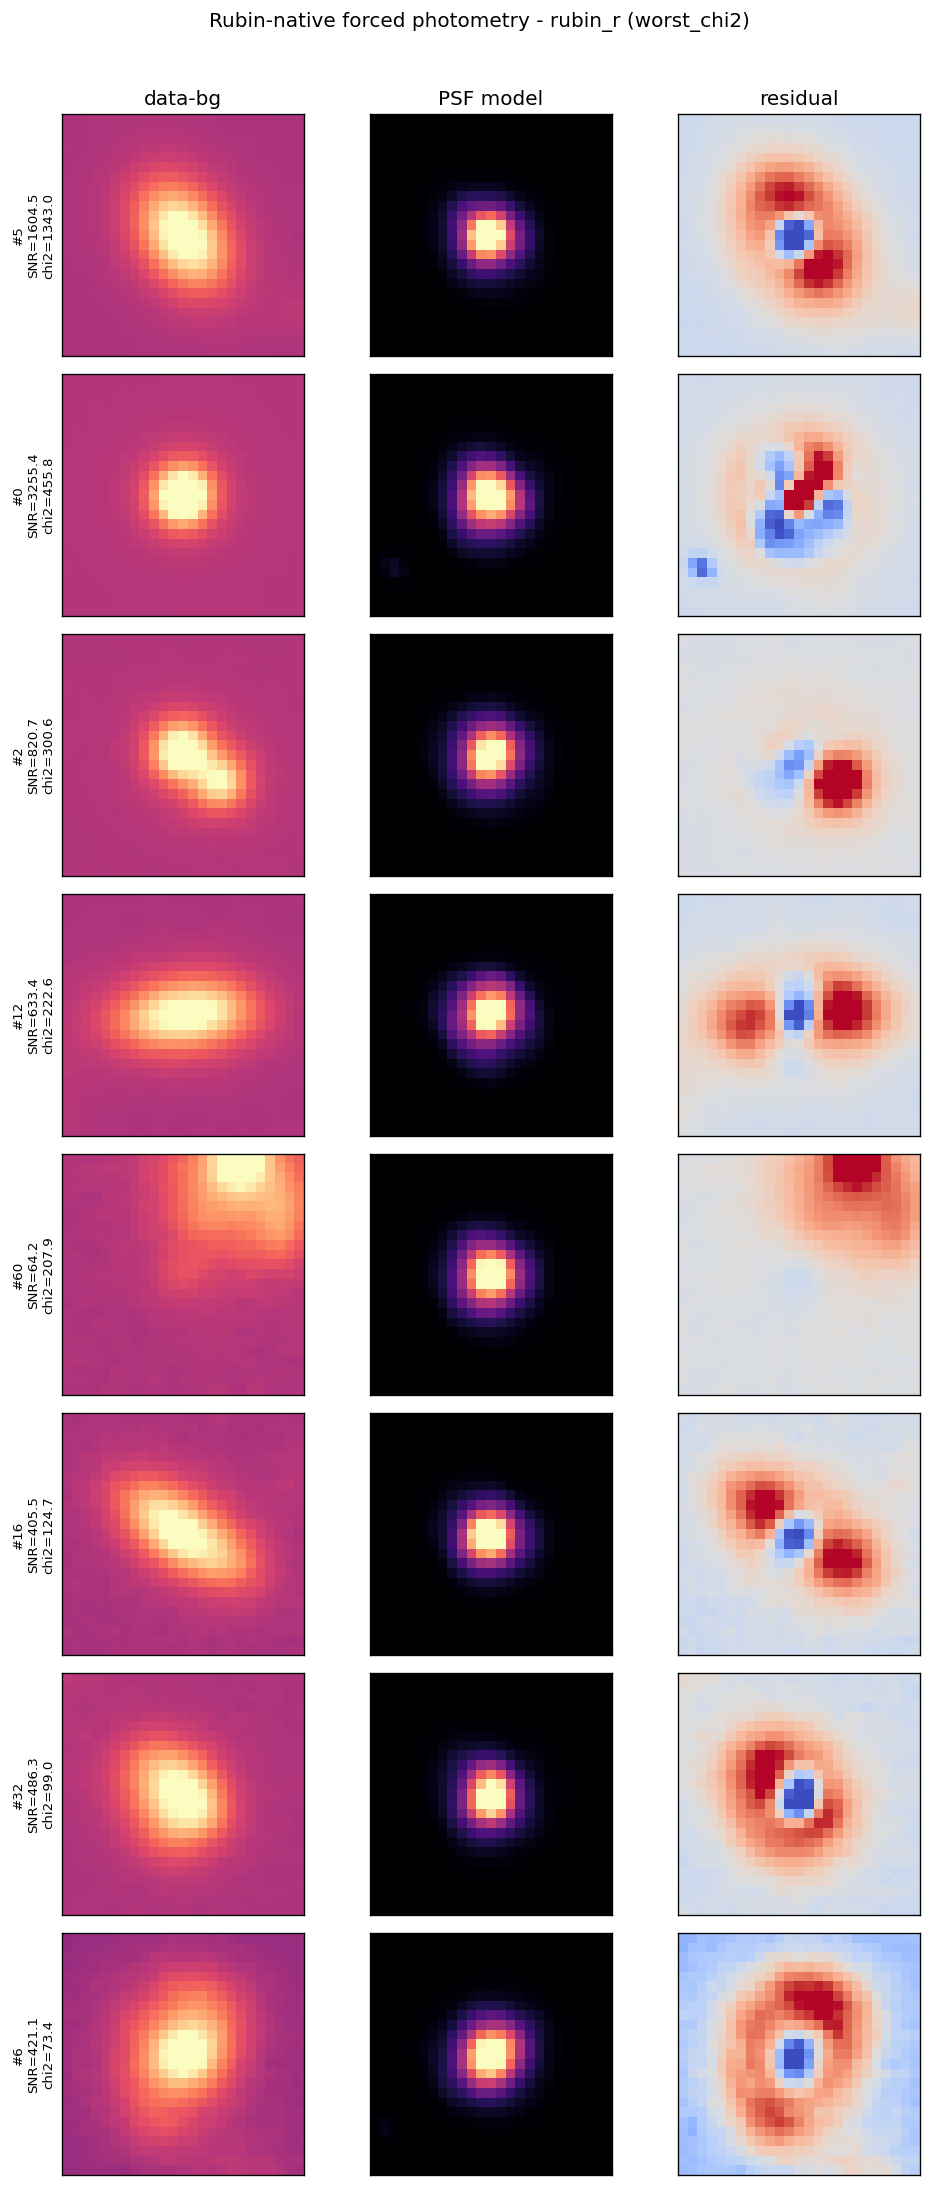

In [7]:
plot_summary(
    rubin_out,
    'Rubin-native PSFField forced photometry',
    save_path=OUT_DIR / 'psf_field_photometry_rubin_summary.png',
)
plot_stamp_gallery(
    rubin_out,
    band=rubin_bands.index('rubin_r'),
    n_show=8,
    mode='good_chi2',
    title='Rubin-native forced photometry',
    save_path=OUT_DIR / 'psf_field_photometry_rubin_good_gallery.png',
)
plot_stamp_gallery(
    rubin_out,
    band=rubin_bands.index('rubin_r'),
    n_show=8,
    mode='worst_chi2',
    title='Rubin-native forced photometry',
    save_path=OUT_DIR / 'psf_field_photometry_rubin_worst_gallery.png',
)


## 4. Euclid-Native Forced Photometry

This runs on the Euclid MER grid. VIS/Y/J/H all share the same tile pixel grid in the NPZ files, so the CenterNet VIS master positions can be used directly for all four Euclid bands.


In [8]:
euclid_bands = ['euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']
euclid_pos = vis_master_pos
print(f'Euclid forced-photometry positions: {len(euclid_pos)}')

euclid_pipe = PSFFieldPhotometryPipeline.from_checkpoint(
    PSF_CKPT,
    band_names=euclid_bands,
    stamp_size=STAMP_SIZE,
    sub_grid=SUB_GRID,
    bg_inner_radius=BG_INNER,
    bg_outer_radius=BG_OUTER,
    device=DEVICE,
)

euclid_out = euclid_pipe.run(
    as_tensor(euclid['img']),
    as_tensor(euclid['rms']),
    euclid_pos,
    return_psfs=True,
    return_stamps=True,
)
summarize_result(euclid_out, 'Euclid-native PSFField forced photometry on CenterNet master catalog')


Euclid forced-photometry positions: 80
Euclid-native PSFField forced photometry on CenterNet master catalog
  flux finite: True
  chi2 finite: True
  N sources: 80, bands: ['euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']
  euclid_VIS  med SNR=   43.28  p90 SNR=  155.13  med chi2=    1.55
  euclid_Y    med SNR=   15.10  p90 SNR=   68.27  med chi2=    0.11
  euclid_J    med SNR=   19.01  p90 SNR=   87.97  med chi2=    0.17
  euclid_H    med SNR=   19.89  p90 SNR=  102.54  med chi2=    0.19


Saved io/psf_field_photometry_euclid_summary.png


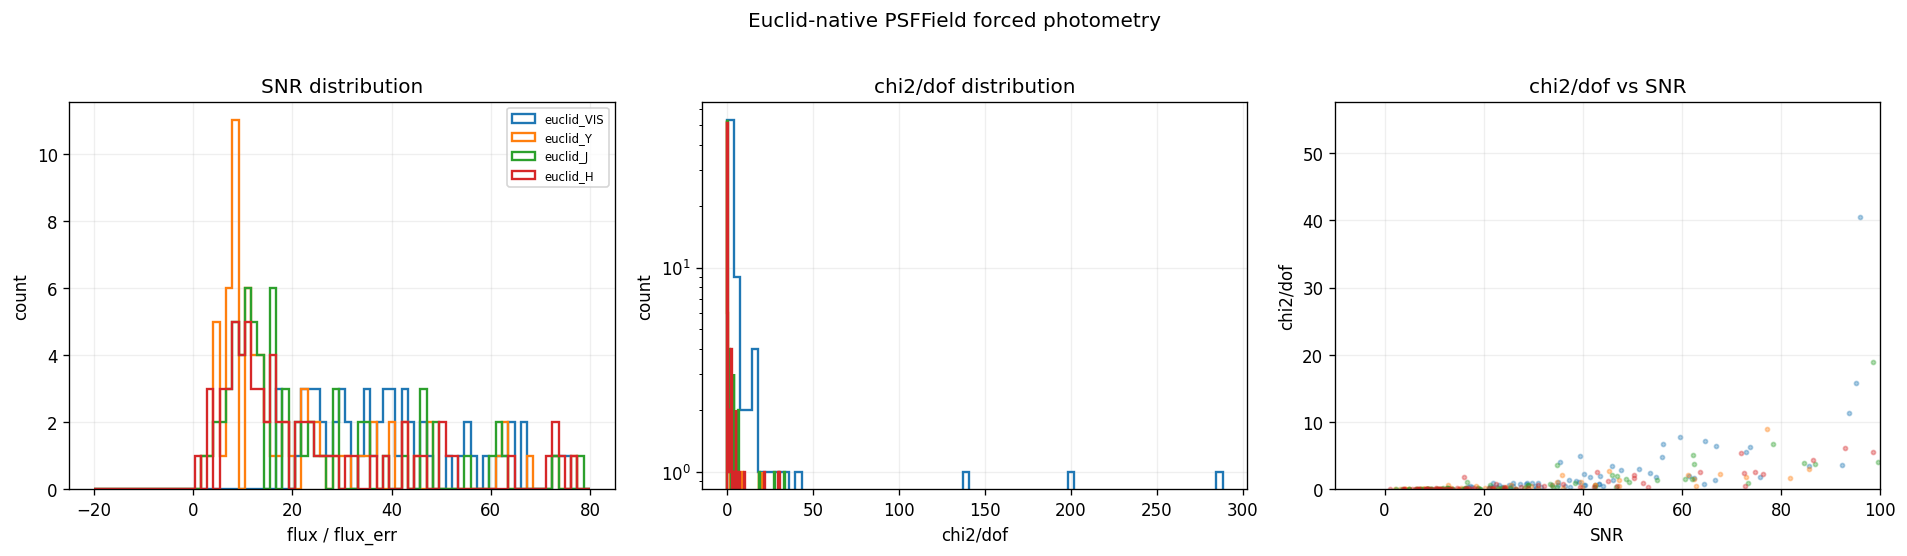

Saved io/psf_field_photometry_euclid_good_gallery.png


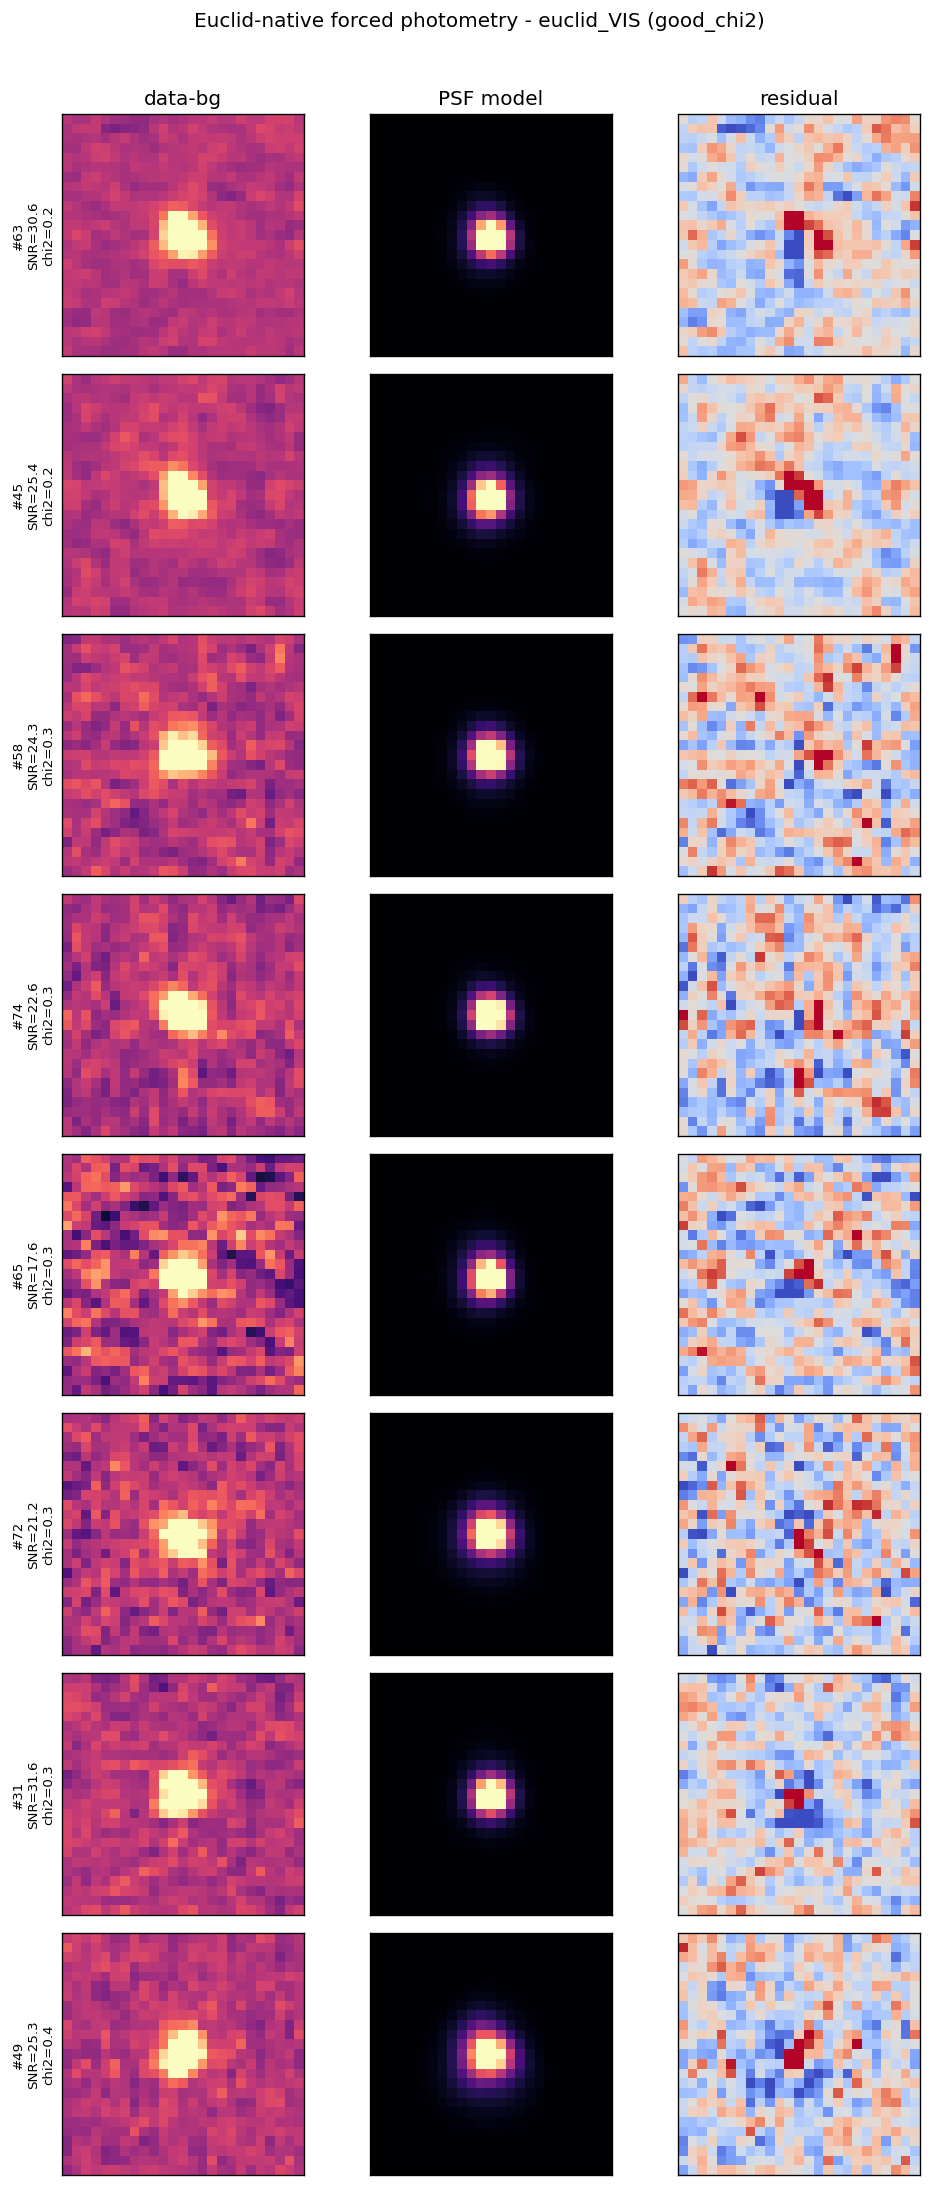

Saved io/psf_field_photometry_euclid_worst_gallery.png


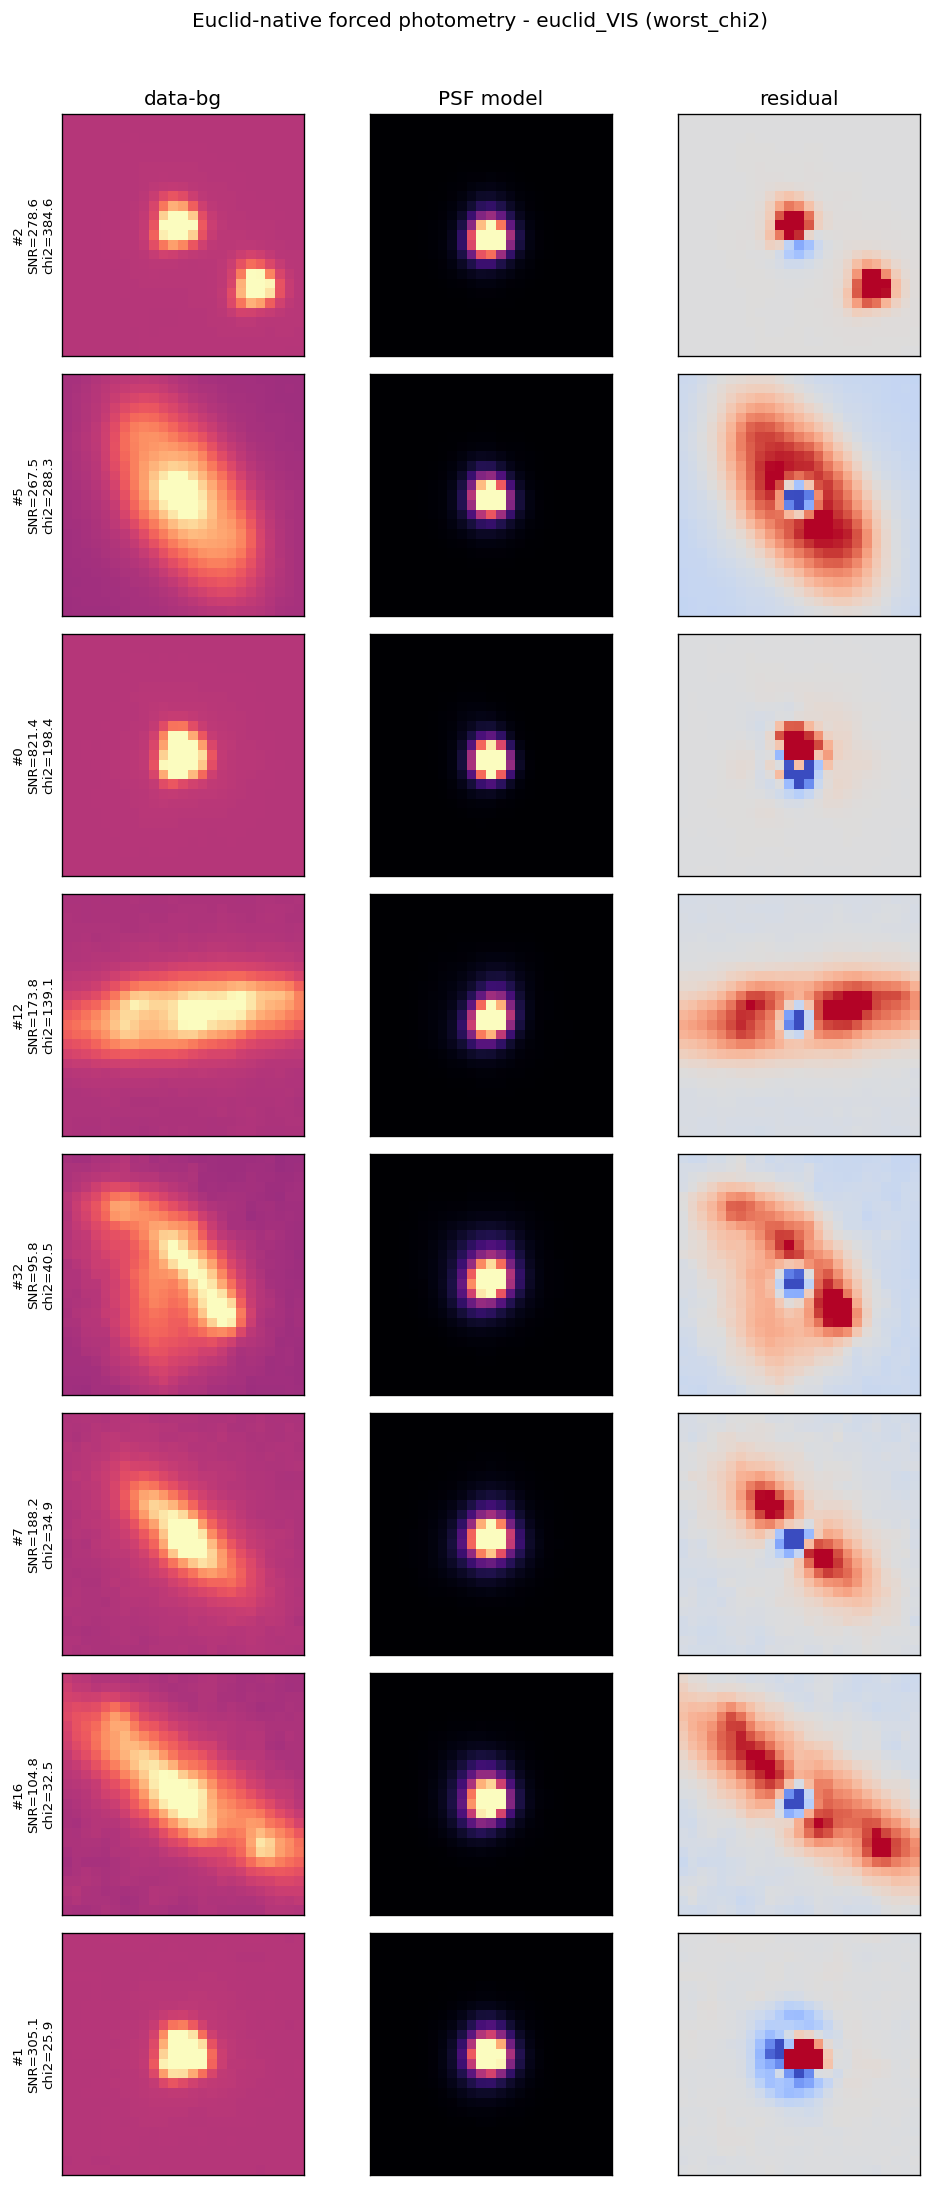

In [9]:
plot_summary(
    euclid_out,
    'Euclid-native PSFField forced photometry',
    save_path=OUT_DIR / 'psf_field_photometry_euclid_summary.png',
)
plot_stamp_gallery(
    euclid_out,
    band=euclid_bands.index('euclid_VIS'),
    n_show=8,
    mode='good_chi2',
    title='Euclid-native forced photometry',
    save_path=OUT_DIR / 'psf_field_photometry_euclid_good_gallery.png',
)
plot_stamp_gallery(
    euclid_out,
    band=euclid_bands.index('euclid_VIS'),
    n_show=8,
    mode='worst_chi2',
    title='Euclid-native forced photometry',
    save_path=OUT_DIR / 'psf_field_photometry_euclid_worst_gallery.png',
)


## 5. Per-Band Position Input Shape

The astrometry head will eventually give us band-specific corrected positions. The pipeline supports this directly through `positions_px` with shape `[N, B, 2]`. This cell demonstrates the interface by applying tiny artificial offsets to the Rubin positions.


In [10]:
# Tiny synthetic per-band shifts, just to validate the shape/API.
base = rubin_pos[: min(20, len(rubin_pos))]
shifts = torch.tensor([
    [0.00, 0.00],
    [0.12, -0.08],
    [-0.07, 0.10],
    [0.05, 0.05],
], dtype=torch.float32)
per_band_pos = base[:, None, :] + shifts[None, :, :]
per_band_out = rubin_pipe.run(rubin_tile, rubin_rms, per_band_pos)
print(f'per_band_pos shape: {tuple(per_band_pos.shape)}')
print(f'flux shape:         {tuple(per_band_out["flux"].shape)}')
print(f'finite flux:        {torch.isfinite(per_band_out["flux"]).all().item()}')
print(f'finite chi2:        {torch.isfinite(per_band_out["chi2_dof"]).all().item()}')


per_band_pos shape: (20, 4, 2)
flux shape:         (20, 4)
finite flux:        True
finite chi2:        True


## 6. Optional Overlap Repeatability Scaffold

This section is disabled by default. Set `RUN_OVERLAP = True` in the configuration cell to run a small repeatability test on overlapping Rubin tiles.

The diagnostic matches repeated detections by sky position and compares PSFField fluxes from different tiles. This is the first internal validation we want before treating the photometry as a science product.


In [11]:
def run_overlap_repeatability(n_tiles=N_OVERLAP_TILES, n_sources=OVERLAP_SOURCES_PER_TILE):
    rows = []
    tids = sorted(pair_map)[:n_tiles]
    pipe = PSFFieldPhotometryPipeline.from_checkpoint(
        PSF_CKPT,
        band_names=['rubin_r', 'rubin_i'],
        stamp_size=17,
        sub_grid=1,
        bg_inner_radius=5.0,
        bg_outer_radius=7.5,
        device=DEVICE,
    )
    for tid in tids:
        rub = load_rubin_tile(pair_map[tid][0])
        pos = detect_rubin_positions(rub, max_sources=n_sources, margin=12)
        if len(pos) == 0:
            continue
        tile = as_tensor(rub['img'][[2, 3]])
        rms = as_tensor(rub['rms'][[2, 3]])
        out = pipe.run(tile, rms, pos)
        ra, dec = rub['wcs'].wcs_pix2world(pos[:, 0].numpy(), pos[:, 1].numpy(), 0)
        flux = out['flux'].detach().cpu().numpy()
        ferr = out['flux_err'].detach().cpu().numpy()
        snr = out['snr'].detach().cpu().numpy()
        chi2 = out['chi2_dof'].detach().cpu().numpy()
        for i in range(len(pos)):
            rows.append({
                'tile_id': tid,
                'ra': ra[i],
                'dec': dec[i],
                'x': float(pos[i, 0]),
                'y': float(pos[i, 1]),
                'flux_r': flux[i, 0],
                'flux_i': flux[i, 1],
                'err_r': ferr[i, 0],
                'err_i': ferr[i, 1],
                'snr_r': snr[i, 0],
                'snr_i': snr[i, 1],
                'chi2_r': chi2[i, 0],
                'chi2_i': chi2[i, 1],
            })
        print(f'{tid}: {len(pos)} sources')
    return rows


def match_repeat_pairs(rows, max_sep_arcsec=0.18):
    if not rows:
        return []
    coords = SkyCoord([r['ra'] for r in rows] * u.deg, [r['dec'] for r in rows] * u.deg)
    i1, i2, sep, _ = coords.search_around_sky(coords, max_sep_arcsec * u.arcsec)
    pairs = []
    for a, b, s in zip(i1, i2, sep.arcsec):
        if a >= b:
            continue
        if rows[a]['tile_id'] == rows[b]['tile_id']:
            continue
        pairs.append((int(a), int(b), float(s)))
    return pairs


if RUN_OVERLAP:
    rows = run_overlap_repeatability()
    pairs = match_repeat_pairs(rows)
    print(f'Rows: {len(rows)}, repeat pairs: {len(pairs)}')
else:
    rows, pairs = [], []
    print('RUN_OVERLAP is False; skipping repeatability run.')


RUN_OVERLAP is False; skipping repeatability run.


In [12]:
if pairs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for band, color in [('r', 'steelblue'), ('i', 'indianred')]:
        pulls, frac, snr_pair = [], [], []
        for a, b, sep in pairs:
            fa, fb = rows[a][f'flux_{band}'], rows[b][f'flux_{band}']
            ea, eb = rows[a][f'err_{band}'], rows[b][f'err_{band}']
            denom = np.sqrt(ea * ea + eb * eb)
            mean_flux = 0.5 * (fa + fb)
            if denom > 0 and np.isfinite(denom):
                pulls.append((fa - fb) / denom)
            if mean_flux > 0 and np.isfinite(mean_flux):
                frac.append((fa - fb) / mean_flux)
                snr_pair.append(min(rows[a][f'snr_{band}'], rows[b][f'snr_{band}']))
        pulls = np.asarray(pulls)
        frac = np.asarray(frac)
        snr_pair = np.asarray(snr_pair)
        axes[0].hist(pulls[np.isfinite(pulls)], bins=np.linspace(-8, 8, 80), histtype='step', lw=1.5, label=f'{band}', color=color)
        axes[1].hist(frac[np.isfinite(frac)], bins=np.linspace(-2, 2, 80), histtype='step', lw=1.5, label=f'{band}', color=color)
        axes[2].scatter(snr_pair, np.abs(frac), s=8, alpha=0.35, label=f'{band}', color=color)
    axes[0].set_title('Repeat flux pulls')
    axes[0].set_xlabel('(f1 - f2) / sqrt(err1^2 + err2^2)')
    axes[0].set_ylabel('count')
    axes[0].legend()
    axes[0].grid(alpha=0.2)
    axes[1].set_title('Repeat fractional flux difference')
    axes[1].set_xlabel('(f1 - f2) / mean(f)')
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    axes[2].set_title('Repeatability vs SNR')
    axes[2].set_xlabel('min repeat SNR')
    axes[2].set_ylabel('|fractional difference|')
    axes[2].set_xscale('log')
    axes[2].set_yscale('log')
    axes[2].legend()
    axes[2].grid(alpha=0.2, which='both')
    plt.tight_layout()
    out = OUT_DIR / 'psf_field_photometry_overlap_repeatability.png'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f'Saved {out.relative_to(ROOT)}')
    plt.show()


## Interpretation Checklist

After running this notebook, inspect:

- Are all flux/error/chi2 values finite?
- Are chi2/dof histograms roughly concentrated, or dominated by huge tails?
- Do the worst-chi2 galleries look like blends/galaxies, PSF mismatch, bad backgrounds, or bad positions?
- Do repeated overlap measurements agree within estimated errors?
- Does repeatability worsen predictably at low SNR?

If the galleries show coherent PSF residuals around isolated stars, improve PSFField. If they show bad centers, feed astrometry-head-corrected per-band positions. If they show galaxy residuals, we need a morphology-aware forced-photometry model rather than a pure PSF template.
